# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Nabilah Yasmin Qasthalani
- Email: qasthalaani@gmail.com
- Id Dicoding: qasthalaani

## Business Understanding

### Latar Belakang
Jaya Jaya Institut merupakan salah satu institusi pendidikan perguruan yang telah berdiri sejak tahun 2000. Hingga saat ini ia telah mencetak banyak lulusan dengan reputasi yang sangat baik. Akan tetapi, terdapat banyak juga siswa yang tidak menyelesaikan pendidikannya alias dropout.

### Permasalahan Bisnis
Jumlah dropout yang tinggi ini tentunya menjadi salah satu masalah yang besar untuk sebuah institusi pendidikan. Oleh karena itu, Jaya Jaya Institut ingin mendeteksi secepat mungkin siswa yang mungkin akan melakukan dropout sehingga dapat diberi bimbingan khusus.



## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Menyiapkan data yang akan digunakan

In [ ]:
df = pd.read_csv("student-data.csv", sep=";")
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Dataset yang digunakan merupakan data historis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

**Insight:** Tidak terdapat adanya missing values pada dataset.

In [ ]:
df.duplicated().sum()

np.int64(0)

**Insight:** Tidak terdapat adanya baris duplikat pada data.

In [ ]:
# Membuat fungsi pengelompokan tingkat risiko dropout
def assign_risk_level(row):
    enrolled = row['Curricular_units_1st_sem_enrolled']
    approved = row['Curricular_units_1st_sem_approved']
    pass_ratio = (approved / enrolled) if enrolled > 0 else 0

    # Kondisi High Risk
    if row['Tuition_fees_up_to_date'] == 0 or pass_ratio < 0.5:
        return 'High'
    # Kondisi Medium Risk
    elif pass_ratio < 0.75 or row['Curricular_units_1st_sem_grade'] < 10:
        return 'Medium'
    # Kondisi Low Risk
    else:
        return 'Low'

# Menerapkan fungsi ke dataframe
df['Risk_Level'] = df.apply(assign_risk_level, axis=1)

# Menampilkan distribusi jumlah mahasiswa per tingkat risiko
print(df['Risk_Level'].value_counts(normalize=True) * 100)

Risk_Level
Low       59.945750
High      28.707052
Medium    11.347197
Name: proportion, dtype: float64


In [ ]:
# 1. Cek distribusi jumlah mahasiswa per tingkat risiko
print("--- Distribusi Risk Level ---")
print(df['Risk_Level'].value_counts(dropna=False))
print("\n--- Persentase Risk Level ---")
print(df['Risk_Level'].value_counts(normalize=True) * 100)

# 2. Cek beberapa contoh baris data untuk memastikan logika bisnisnya tepat
df[['Tuition_fees_up_to_date', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_enrolled', 'Risk_Level']].head(10)

--- Distribusi Risk Level ---
Risk_Level
Low       2652
High      1270
Medium     502
Name: count, dtype: int64

--- Persentase Risk Level ---
Risk_Level
Low       59.945750
High      28.707052
Medium    11.347197
Name: proportion, dtype: float64


,Tuition_fees_up_to_date,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_enrolled,Risk_Level
0,1,0,0,High
1,0,6,6,High
2,0,0,6,High
3,1,6,6,Low
4,1,5,6,Low
5,1,5,5,Low
6,1,7,7,Low
7,0,0,5,High
8,1,6,6,Low
9,0,5,6,High


In [ ]:
# mapping course

import pandas as pd

# 1. Buat dictionary pemetaan kode ke nama program studi
course_mapping = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)'
}

# 2. Terapkan ke DataFrame kamu (asumsi kolom lama bernama 'Course')
# Kita buat kolom baru 'course_name' agar data numerik aslinya tetap aman
df['course_name'] = df['Course'].map(course_mapping)

# 3. Opsional: Cek jika ada kode yang belum ter-mapping (menghasilkan NaN)
print("Jumlah data tanpa label:", df['course_name'].isna().sum())

Jumlah data tanpa label: 0


In [ ]:
df.head(10)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Risk_Level,course_name
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0.000000,0,10.8,1.4,1.74,Dropout,High,Animation and Multimedia Design
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,High,Tourism
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0.000000,0,10.8,1.4,1.74,Dropout,High,Communication Design
3,1,17,2,9773,1,1,122.0,1,38,37,...,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,Low,Journalism and Communication
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,Low,Social Service (evening attendance)
5,2,39,1,9991,0,19,133.1,1,37,37,...,17,5,11.500000,5,16.2,0.3,-0.92,Graduate,Low,Management (evening attendance)
6,1,1,1,9500,1,1,142.0,1,19,38,...,8,8,14.345000,0,15.5,2.8,-4.06,Graduate,Low,Nursing
7,1,18,4,9254,1,1,119.0,1,37,37,...,5,0,0.000000,0,15.5,2.8,-4.06,Dropout,High,Tourism
8,1,1,3,9238,1,1,137.0,62,1,1,...,7,6,14.142857,0,16.2,0.3,-0.92,Graduate,Low,Social Service
9,1,1,1,9238,1,1,138.0,1,1,19,...,14,2,13.500000,0,8.9,1.4,3.51,Dropout,High,Social Service


In [ ]:
# Buat Student ID sintetis (contoh: STD230001, STD230002, dst)
df.insert(0, 'Student_ID', ['STD26' + str(i).zfill(4) for i in range(1, len(df) + 1)])

In [ ]:
# simpan df ke dalam bentuk csv
df.to_csv("student-data-clean.csv", index=False)

## EDA

In [ ]:
df_clean = pd.read_csv("student-data-clean.csv")
df_clean.head()

,Student_ID,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,...,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Risk_Level,course_name
0,STD260001,1,17,5,171,1,1,122.0,1,19,...,0,0,0.000000,0,10.8,1.4,1.74,Dropout,High,Animation and Multimedia Design
1,STD260002,1,15,1,9254,1,1,160.0,1,1,...,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,High,Tourism
2,STD260003,1,1,5,9070,1,1,122.0,1,37,...,0,0,0.000000,0,10.8,1.4,1.74,Dropout,High,Communication Design
3,STD260004,1,17,2,9773,1,1,122.0,1,38,...,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,Low,Journalism and Communication
4,STD260005,2,39,1,8014,0,1,100.0,1,37,...,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,Low,Social Service (evening attendance)


In [ ]:
df_clean.describe(include="all")

,Student_ID,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,...,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Risk_Level,course_name
count,4424,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424,4424,4424
unique,4424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,17
top,STD264424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate,Low,Nursing
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209,2652,766
mean,NaN,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,...,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN,NaN,NaN
std,NaN,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,...,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN,NaN,NaN
min,NaN,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN,NaN,NaN
25%,NaN,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,...,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN,NaN,NaN
50%,NaN,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,...,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN,NaN,NaN
75%,NaN,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,...,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN,NaN,NaN


In [ ]:
# lihat dropout rate
dropout_rate = (df_clean['Status'].value_counts() / len(df_clean)) * 100
print(dropout_rate)

Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: count, dtype: float64


**Insight:** Hasil analisis diatas menunjukkan bahwa ada 32,1% siswa yang Dropout(keluar). Sementara itu persentase mahasiswa yang Graduate (lulus) adalah 49,93% dan mahasiswa yang baru masuk ada sekitar 17.94%. Jumlah mahasiswa yang baru masuk hampir 50% lebih sedikit dibanding mahasiswa yang keluar karena Dropout.

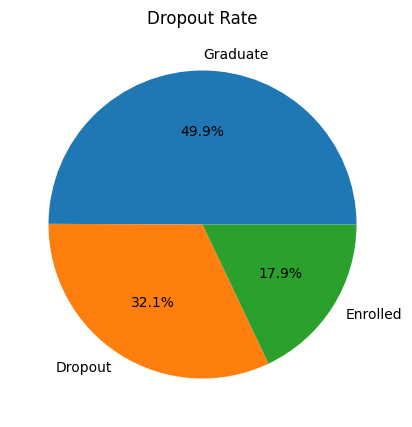

In [ ]:
# visualisasi dropout rate
plt.figure(figsize=(5,5))
plt.pie(dropout_rate, labels=dropout_rate.index, autopct='%1.1f%%')
plt.title('Dropout Rate')
plt.show()

In [ ]:
# analisis dropout rate berdasarkan course yang diambil oleh mahasiswa
course_status_percentages = (
    pd.crosstab(df_clean['Course'], df_clean['Status'], normalize='index') * 100
)

print(course_status_percentages.head(5))

Status    Dropout   Enrolled   Graduate
Course                                 
33      66.666667  25.000000   8.333333
171     38.139535  17.209302  44.651163
8014    33.023256   9.767442  57.209302
9003    40.952381  17.619048  41.428571
9070    22.566372  18.584071  58.849558


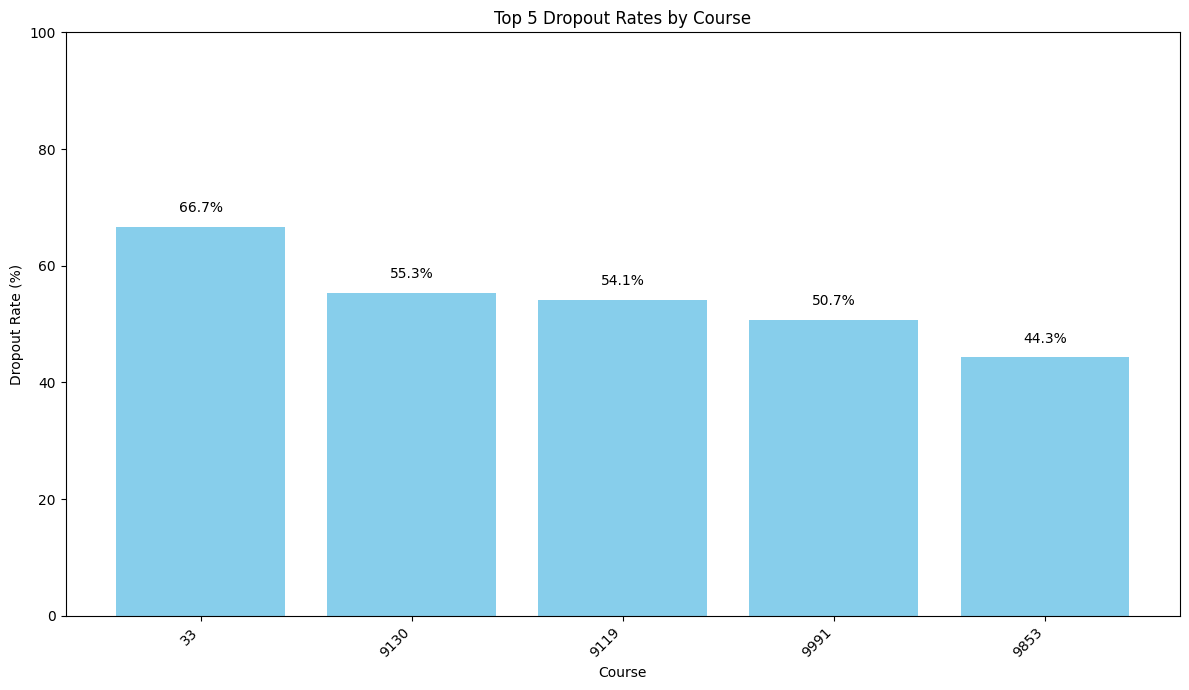

In [ ]:
import matplotlib.pyplot as plt

# Sort by Dropout and get top 5 courses
top_5_course_dropout = course_status_percentages.sort_values(by='Dropout', ascending=False).head(5)

# visualisasi dropout rate berdasarkan course dengan bar chart (Top 5)
plt.figure(figsize=(12, 7))
bars = plt.bar(
    top_5_course_dropout.index.astype(str),
    top_5_course_dropout['Dropout'],
    color='skyblue',
)

plt.title('Top 5 Dropout Rates by Course')
plt.xlabel('Course')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)  # Batas sumbu Y hingga 100% agar skala jelas
plt.xticks(rotation=45, ha='right')

# Menambahkan label angka di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 2,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

**Insight:** Dari hasil analisis dan visualisasi, mahasiswa dengan jurusan 33 (Biofuel Production Technologies) menjadi yang terbanyak melakukan Dropout dengan persentase mencapai 66,67%. Posisi kedua jurusan dengan dropout rate tertinggi adalah jurusan 9130 (Equinculture) dengan persentase 55,31%, diikuti oleh jurusan 9119 (Informatics Engineering) dengan persentase 54.11%.

Analisis lanjutan diperlukan untuk melihat faktor apa saja yang memengaruhi tingginya dropout rate pada jurusan tersebut.

In [ ]:
# analisis dropout rate berdasarkan attendance
attendance_dropout = (
    pd.crosstab(df_clean['Daytime_evening_attendance'], df_clean['Status'], normalize='index') * 100
)

print(attendance_dropout)

Status                        Dropout  Enrolled   Graduate
Daytime_evening_attendance                                
0                           42.857143  15.52795  41.614907
1                           30.804364  18.24410  50.951535


**Insight:** Mahasiswa yang berkuliah sore (0) lebih tinggi dropout rate nya dibanding mahasiswa yang berkuliah di pagi hari (1).

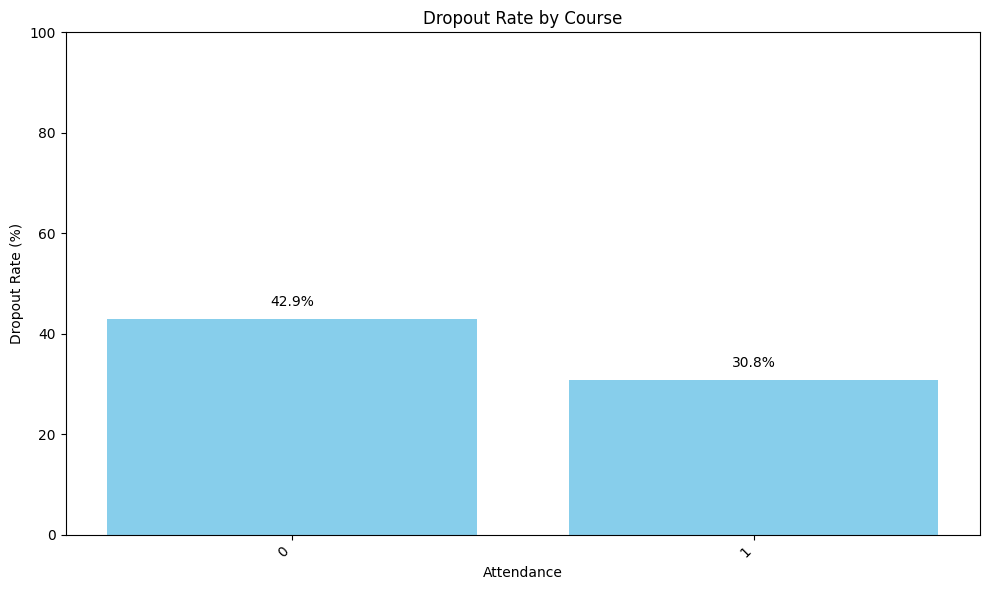

In [ ]:
# visualisasi dropout rate menggunakan pie chart
# visualisasi dropout rate berdasarkan course dengan bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(
    attendance_dropout.index.astype(str),
    attendance_dropout['Dropout'],
    color='skyblue',
)

plt.title('Dropout Rate by Course')
plt.xlabel('Attendance')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)  # Batas sumbu Y hingga 100% agar skala jelas
plt.xticks(rotation=45, ha='right')

# Menambahkan label angka di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 2,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

In [ ]:
# analisis dropout rate berdasarkan pendidikan terakhir
previous_qualification_dropout = (
    pd.crosstab(df_clean['Previous_qualification'], df_clean['Status'], normalize='index') * 100
)

print(previous_qualification_dropout.head(5))

Status                     Dropout   Enrolled   Graduate
Previous_qualification                                  
1                        29.001883  18.778585  52.219532
2                        69.565217   4.347826  26.086957
3                        59.523810   3.174603  37.301587
4                        50.000000  12.500000  37.500000
5                       100.000000   0.000000   0.000000


**Insight:**

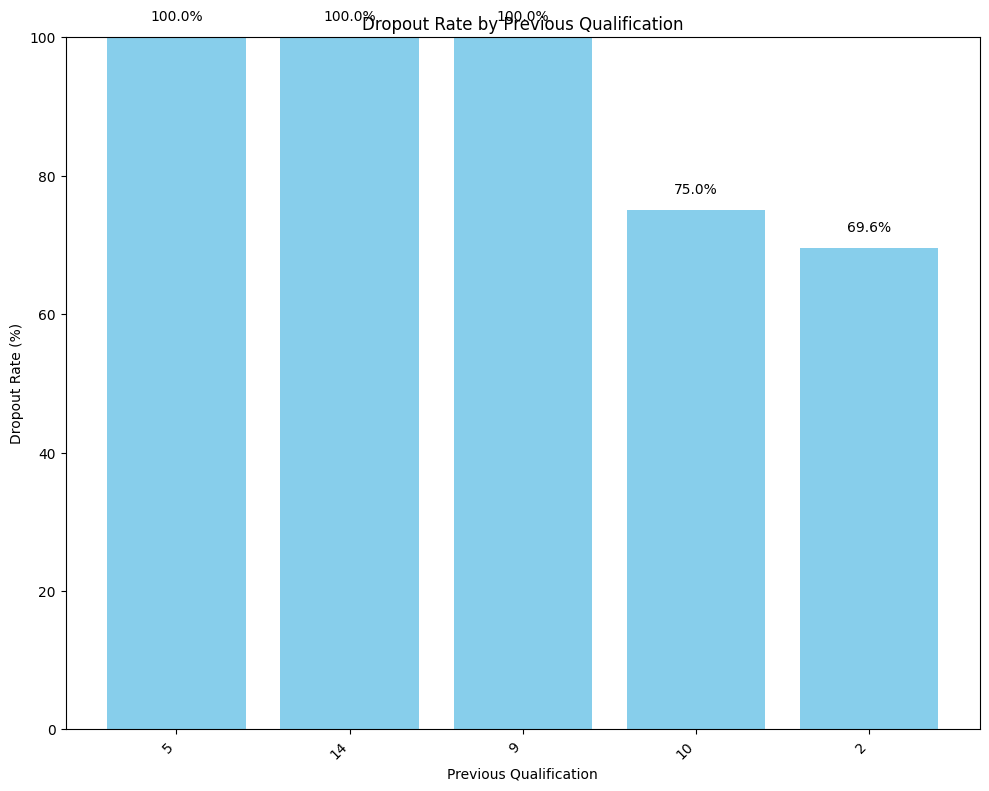

In [ ]:
top_5_qualification_dropout = previous_qualification_dropout.sort_values(by='Dropout', ascending=False).head(5)

# visualisasi droprate berdasarkan pendidikan terakhir dengan bar chart
plt.figure(figsize=(10, 8))
bars = plt.bar(
    top_5_qualification_dropout.index.astype(str),
    top_5_qualification_dropout['Dropout'],
    color='skyblue',
)

plt.title('Dropout Rate by Previous Qualification')
plt.xlabel('Previous Qualification')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)  # Batas sumbu Y hingga 100% agar skala jelas
plt.xticks(rotation=45, ha='right')

# Menambahkan label angka di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 2,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

In [ ]:
#  analisis dropout rate berdasarkan negara asal (nationality)
nationality_dropout = (
    pd.crosstab(df_clean['Nacionality'], df_clean['Status'], normalize='index') * 100
)

print(nationality_dropout.head(10))

Status          Dropout   Enrolled    Graduate
Nacionality                                   
1             32.197497  17.848864   49.953639
2              0.000000   0.000000  100.000000
6             30.769231  38.461538   30.769231
11             0.000000   0.000000  100.000000
13             0.000000   0.000000  100.000000
14             0.000000   0.000000  100.000000
17           100.000000   0.000000    0.000000
21            50.000000  50.000000    0.000000
22            30.769231   7.692308   61.538462
24            20.000000   0.000000   80.000000


**Insight:**

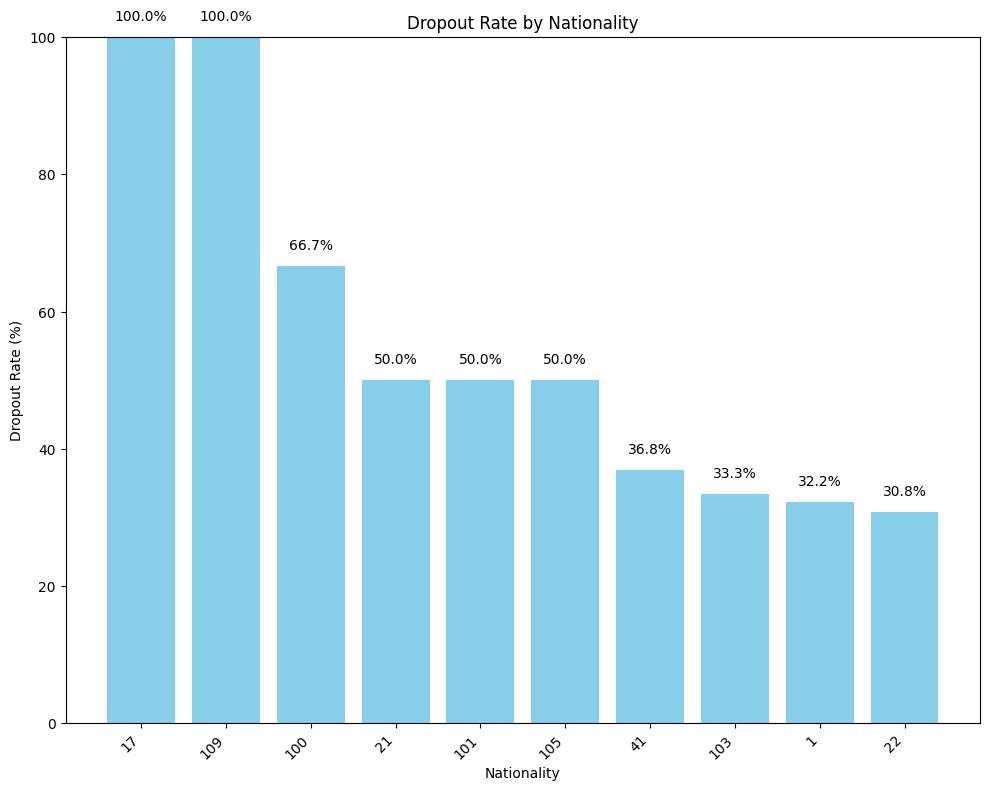

In [ ]:
# visualisasi dropout berdasarkan nationality
top_10_nationality_dropout = nationality_dropout.sort_values(by='Dropout', ascending=False).head(10)

# visualisasi droprate berdasarkan pendidikan terakhir dengan bar chart
plt.figure(figsize=(10, 8))
bars = plt.bar(
    top_10_nationality_dropout.index.astype(str),
    top_10_nationality_dropout['Dropout'],
    color='skyblue',
)

plt.title('Dropout Rate by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)  # Batas sumbu Y hingga 100% agar skala jelas
plt.xticks(rotation=45, ha='right')

# Menambahkan label angka di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 2,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

In [ ]:
# Analisis dropout rate berdasarkan admission grade
admission_grade_dropout = (
    pd.crosstab(df_clean['Admission_grade'], df_clean['Status'], normalize='index') * 100
)

print(admission_grade_dropout.head(10))

Status              Dropout   Enrolled    Graduate
Admission_grade                                   
95.0              63.636364   9.090909   27.272727
95.1             100.000000   0.000000    0.000000
95.5              50.000000   0.000000   50.000000
95.8             100.000000   0.000000    0.000000
96.0              71.428571  28.571429    0.000000
96.1             100.000000   0.000000    0.000000
96.7             100.000000   0.000000    0.000000
97.0              50.000000  16.666667   33.333333
97.2               0.000000   0.000000  100.000000
97.4             100.000000   0.000000    0.000000


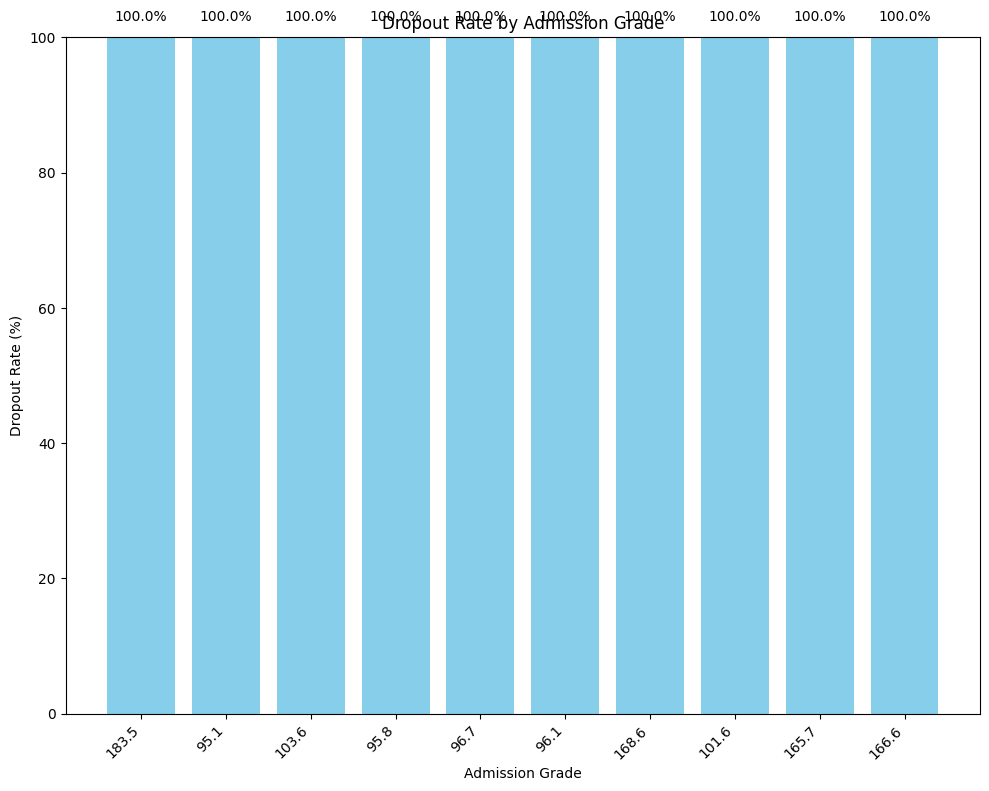

In [ ]:
# Visualisasi dropout rate berdasarkan admission grade (top 10) dengan bar chart
top_10_grade_dropout = admission_grade_dropout.sort_values(by='Dropout', ascending=False).head(10)

plt.figure(figsize=(10, 8))
bars = plt.bar(
    top_10_grade_dropout.index.astype(str),
    top_10_grade_dropout['Dropout'],
    color='skyblue',
)

plt.title('Dropout Rate by Admission Grade')
plt.xlabel('Admission Grade')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)  # Batas sumbu Y hingga 100% agar skala jelas
plt.xticks(rotation=45, ha='right')

# Menambahkan label angka di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 2,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

In [ ]:
# dropout rate antara mahasiswa yang debitur dan yang tidak
debtor_dropout = (
    pd.crosstab(df_clean['Debtor'], df_clean['Status'], normalize='index') * 100
)

print(debtor_dropout)

Status    Dropout   Enrolled   Graduate
Debtor                                 
0       28.283601  17.954603  53.761795
1       62.027833  17.892644  20.079523


**Insight:** Mahasiswa yang merupakan debitur (mempunyai hutang) lebih banyak dropout daripada mahasiwa yang bukan debitur (tidak memiliki hutang)

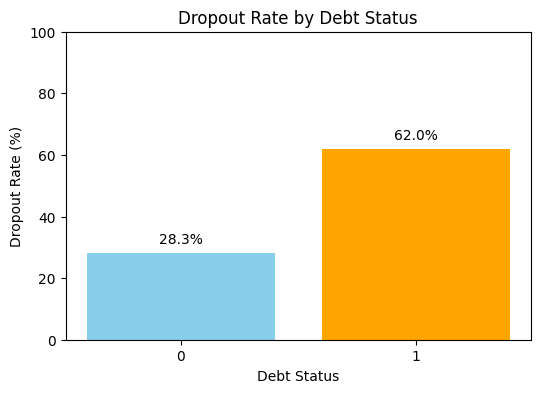

In [ ]:
# visualisasi dropout rate berdasarkan debt status percentage
plt.figure(figsize=(6, 4))
bars = plt.bar(
    debtor_dropout.index.astype(str),
    debtor_dropout['Dropout'],
    color=['skyblue', 'orange'],
)

plt.title('Dropout Rate by Debt Status')
plt.xlabel('Debt Status')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)  # Batas sumbu Y hingga 100% agar skala jelas

# Menambahkan label angka di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 2,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
    )

plt.show()

In [ ]:
# dropout rate berdasarkan gender
gender_status_breakdown = (
    pd.crosstab(df_clean['Gender'], df_clean['Status'], normalize='index') * 100
)

print(gender_status_breakdown)

Status    Dropout   Enrolled   Graduate
Gender                                 
0       25.104603  16.980474  57.914923
1       45.051414  19.730077  35.218509


**Insight:** Mahasiswa laki-laki cenderung lebih banyak melakukan dropout daripada mahasiswa perempuan.

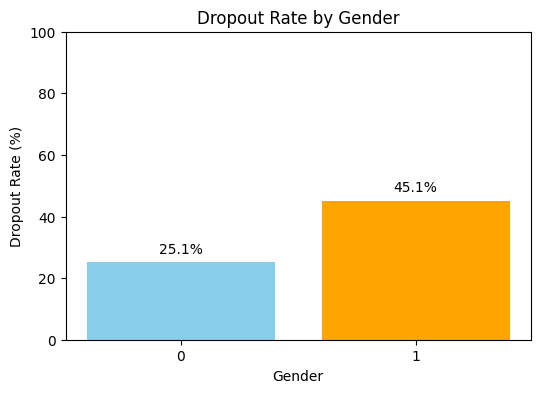

In [ ]:
# visualisasi drop out rate berdasarkan gender
plt.figure(figsize=(6, 4))
bars = plt.bar(
    gender_status_breakdown.index.astype(str),
    gender_status_breakdown['Dropout'],
    color=['skyblue', 'orange'],
)

plt.title('Dropout Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)  # Batas sumbu Y hingga 100% agar skala jelas

# Menambahkan label angka di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 2,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
    )

plt.show()

In [ ]:
# analisis dropout rate berdasarkan scholarship holder
scholarship_status = (
    pd.crosstab(df_clean['Scholarship_holder'], df_clean['Status'], normalize='index') * 100
)

print(scholarship_status)

Status                Dropout   Enrolled   Graduate
Scholarship_holder                                 
0                   38.706767  19.969925  41.323308
1                   12.192903  11.828935  75.978162


**Insight:** Hasil analisis menunjukkan bahwa pemegang beasiswa cenderung tidak dropout dibanding mahasiswa yang tidak mendapatkan beasiswa.

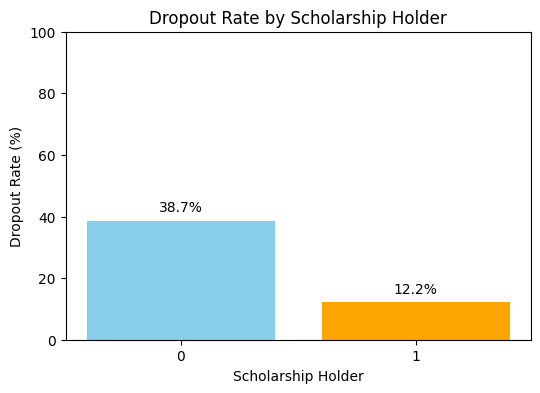

In [ ]:
# visualisasi dropout rate berdasarkan scholarship holder dengan pie chart
plt.figure(figsize=(6, 4))
bars = plt.bar(
    scholarship_status.index.astype(str),
    scholarship_status['Dropout'],
    color=['skyblue', 'orange'],
)

plt.title('Dropout Rate by Scholarship Holder')
plt.xlabel('Scholarship Holder')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)  # Batas sumbu Y hingga 100% agar skala jelas

# Menambahkan label angka di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 2,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
    )

plt.show()

In [ ]:
# analisis dropout rate berdasarkan usia saat masuk kuliah
# membagi usia ke dalam beberapa kelompok: (16-25), (25-35), (35-55), (55-70)
bins = [16, 25, 35, 55, 70]
labels = ['17-25', '26-35', '36-55', '56-70']

# Buat kolom baru 'Age_Group'
df_clean['Age_Group'] = pd.cut(df_clean['Age_at_enrollment'], bins=bins, labels=labels)

# Hitung Analysis Dropout Rate per Kelompok Usia
age_group_crosstab = (
    pd.crosstab(df_clean['Age_Group'], df_clean['Status'], normalize='index') * 100
)

# Ambil kolom Dropout saja
age_group_dropout = age_group_crosstab['Dropout']
print(age_group_crosstab)

Status       Dropout   Enrolled   Graduate
Age_Group                                 
17-25      24.770642  19.325244  55.904114
26-35      57.580398  14.395100  28.024502
36-55      53.034301  12.401055  34.564644
56-70      53.846154   0.000000  46.153846


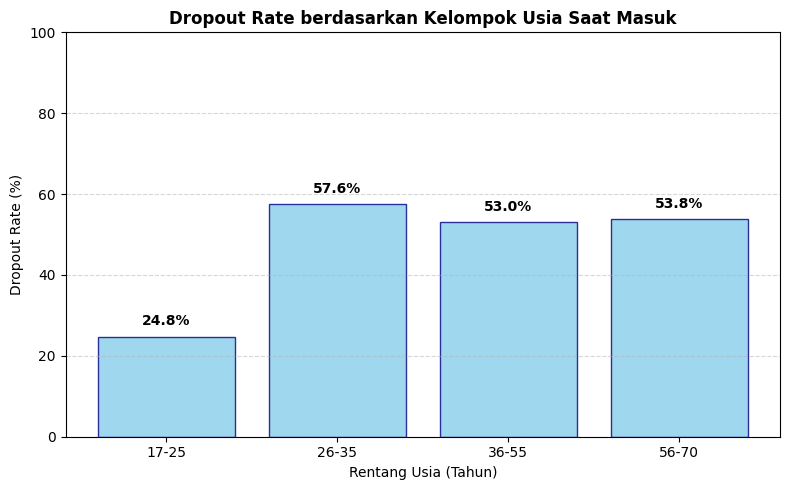

In [ ]:
# visualisasi dropout rate berdasarkan usia masuk
plt.figure(figsize=(8, 5))
bars = plt.bar(
    age_group_dropout.index.astype(str),
    age_group_dropout.values,
    color='skyblue',
    edgecolor='navy',
    alpha=0.8,
)

plt.title(
    'Dropout Rate berdasarkan Kelompok Usia Saat Masuk',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Rentang Usia (Tahun)', fontsize=10)
plt.ylabel('Dropout Rate (%)', fontsize=10)
plt.ylim(0, 100)  # Skala 0-100%
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan label persentase di atas setiap batang
for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      yval + 2,
      f'{yval:.1f}%',
      ha='center',
      va='bottom',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

In [ ]:
# analisis dropout berdasarkan perbandingan mahasiswa internasional dan lokal
international_status = (
    pd.crosstab(df_clean['International'], df_clean['Status'], normalize='index') * 100
)

print(international_status)

Status           Dropout   Enrolled   Graduate
International                                 
0              32.197497  17.848864  49.953639
1              29.090909  21.818182  49.090909


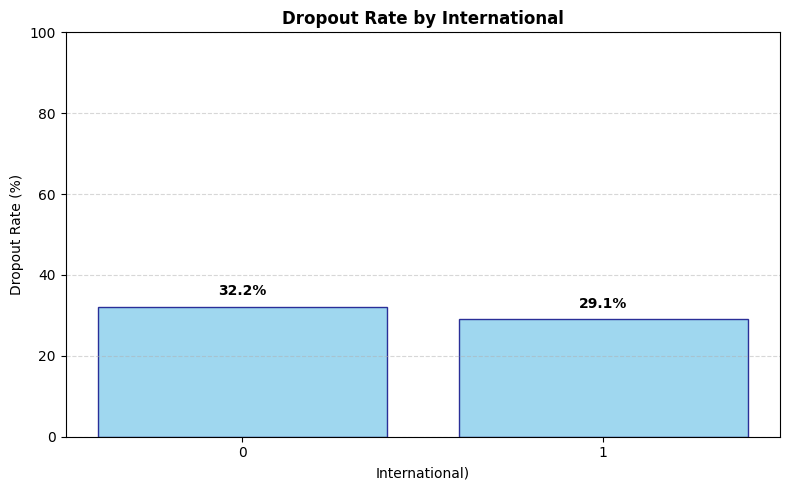

In [ ]:
# visualisasi dropout berdasarkan perbandingan mahasiswa internasional dan lokal
plt.figure(figsize=(8, 5))
bars = plt.bar(
    international_status.index.astype(str),
    international_status['Dropout'],
    color='skyblue',
    edgecolor='navy',
    alpha=0.8,
)

plt.title(
    'Dropout Rate by International',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('International)', fontsize=10)
plt.ylabel('Dropout Rate (%)', fontsize=10)
plt.ylim(0, 100)  # Skala 0-100%
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan label persentase di atas setiap batang
for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      yval + 2,
      f'{yval:.1f}%',
      ha='center',
      va='bottom',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

In [ ]:
# analisis dropout rate by nilai rata-rata mata kuliah di semester 1
avg_grade = df_clean.groupby('Status')['Curricular_units_1st_sem_grade'].mean().reset_index()
print(avg_grade)

     Status  Curricular_units_1st_sem_grade
0   Dropout                        7.256656
1  Enrolled                       11.125257
2  Graduate                       12.643655


**Insight:** Hasil analisis menunjukkan bahwa mahasiswa yang dropout memiliki nilai rata-rata nilai 7,25 pada semester 1.

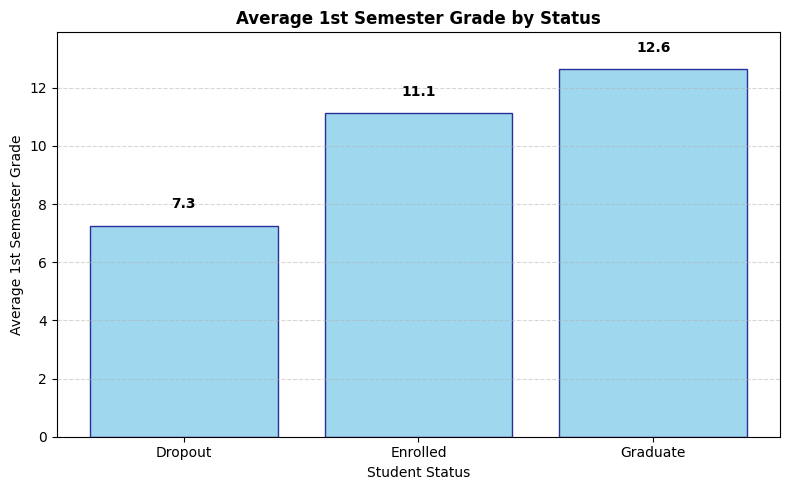

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_grade['Status'],
    avg_grade['Curricular_units_1st_sem_grade'],
    color='skyblue',
    edgecolor='navy',
    alpha=0.8,
)

plt.title(
    'Average 1st Semester Grade by Status',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Student Status', fontsize=10)
plt.ylabel('Average 1st Semester Grade', fontsize=10)
plt.ylim(0, avg_grade['Curricular_units_1st_sem_grade'].max() * 1.1)  # Adjust y-limit dynamically
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan label nilai di atas setiap batang
for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      yval + 0.5,
      f'{yval:.1f}',
      ha='center',
      va='bottom',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

In [ ]:
# analisis dropout rate by jumlah rata2 mata kuliah yang lulus di sem 1
avg_curricular_approved = df_clean.groupby('Status')['Curricular_units_1st_sem_approved'].mean().reset_index()
print(avg_curricular_approved)

     Status  Curricular_units_1st_sem_approved
0   Dropout                           2.551724
1  Enrolled                           4.318640
2  Graduate                           6.232232


**Insight:** Mahasiswa yang dropout rata-rata hanya memiliki 2 mata kuliah yang lulus di semester 1.

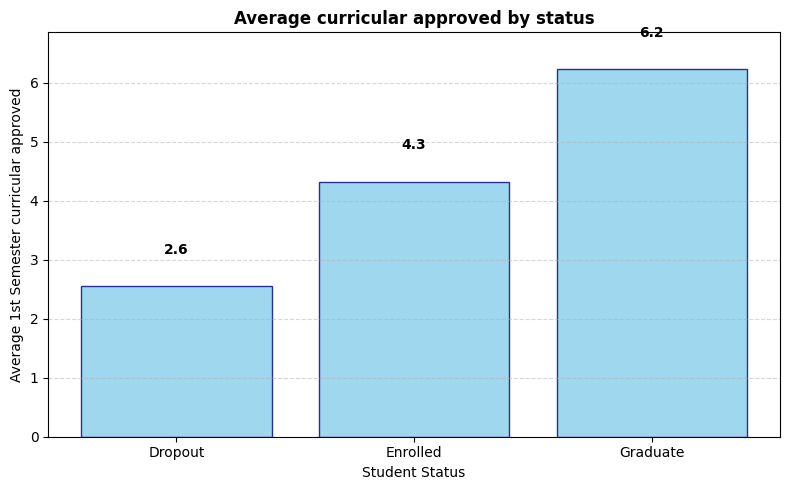

In [ ]:
# visualisasi dropout rate by jumlah rata2 mata kuliah yang lulus di sem 1
plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_curricular_approved['Status'],
    avg_curricular_approved['Curricular_units_1st_sem_approved'],
    color='skyblue',
    edgecolor='navy',
    alpha=0.8,
)

plt.title(
    'Average curricular approved by status',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Student Status', fontsize=10)
plt.ylabel('Average 1st Semester curricular approved', fontsize=10)
plt.ylim(0, avg_curricular_approved['Curricular_units_1st_sem_approved'].max() * 1.1)  # Adjust y-limit dynamically
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan label nilai di atas setiap batang
for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      yval + 0.5,
      f'{yval:.1f}',
      ha='center',
      va='bottom',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

In [ ]:
# analisis dropout rate by nilai rata-rata mata kuliah di semester 2
avg_grade_2 = df_clean.groupby('Status')['Curricular_units_2nd_sem_grade'].mean().reset_index()
print(avg_grade_2)

     Status  Curricular_units_2nd_sem_grade
0   Dropout                        5.899339
1  Enrolled                       11.117364
2  Graduate                       12.697276


**Insight:** Mahasiswa yang dropout memiliki nilai rata-rata 5,8 di semester 2

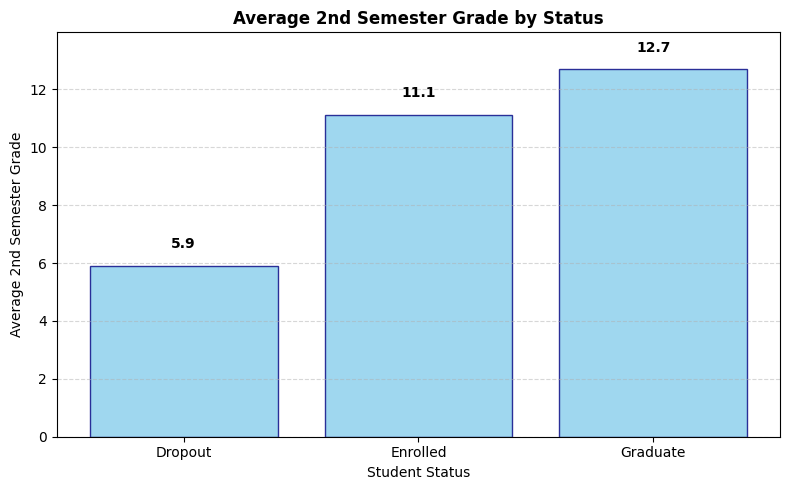

In [ ]:
# visualisasi dropout rate by nilai rata-rata mata kuliah di semester 2
plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_grade_2['Status'],
    avg_grade_2['Curricular_units_2nd_sem_grade'],
    color='skyblue',
    edgecolor='navy',
    alpha=0.8,
)

plt.title(
    'Average 2nd Semester Grade by Status',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Student Status', fontsize=10)
plt.ylabel('Average 2nd Semester Grade', fontsize=10)
plt.ylim(0, avg_grade_2['Curricular_units_2nd_sem_grade'].max() * 1.1)  # Adjust y-limit dynamically
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan label nilai di atas setiap batang
for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      yval + 0.5,
      f'{yval:.1f}',
      ha='center',
      va='bottom',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

In [ ]:
# analisis dropout rate by rata-rata jumlah mata kuliah yang lulus di semester 2
avg_curricular_approved_2 = df_clean.groupby('Status')['Curricular_units_2nd_sem_approved'].mean().reset_index()
print(avg_curricular_approved_2)

     Status  Curricular_units_2nd_sem_approved
0   Dropout                           1.940183
1  Enrolled                           4.057935
2  Graduate                           6.177003


**Insight:** Mahasiswa yang dropout memiliki rata-rata jumlah mata kuliah yang lulus dibawah 2.

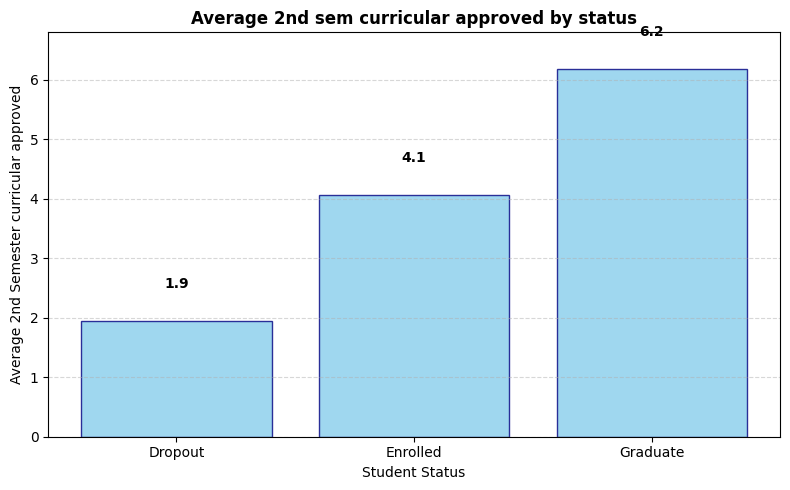

In [ ]:
# visualisasi dropout rate by rata-rata jumlah mata kuliah yang lulus di semester 2
plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_curricular_approved_2['Status'],
    avg_curricular_approved_2['Curricular_units_2nd_sem_approved'],
    color='skyblue',
    edgecolor='navy',
    alpha=0.8,
)

plt.title(
    'Average 2nd sem curricular approved by status',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Student Status', fontsize=10)
plt.ylabel('Average 2nd Semester curricular approved', fontsize=10)
plt.ylim(0, avg_curricular_approved_2['Curricular_units_2nd_sem_approved'].max() * 1.1)  # Adjust y-limit dynamically
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan label nilai di atas setiap batang
for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      yval + 0.5,
      f'{yval:.1f}',
      ha='center',
      va='bottom',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

## Feature Encoding

In [ ]:
# label encode kolom ordinal
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Course']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le

df_clean.head()

,Student_ID,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,...,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Risk_Level,course_name,Age_Group
0,STD260001,1,17,5,1,1,1,122.0,1,19,...,0,0.000000,0,10.8,1.4,1.74,Dropout,High,Animation and Multimedia Design,17-25
1,STD260002,1,15,1,10,1,1,160.0,1,1,...,6,13.666667,0,13.9,-0.3,0.79,Graduate,High,Tourism,17-25
2,STD260003,1,1,5,4,1,1,122.0,1,37,...,0,0.000000,0,10.8,1.4,1.74,Dropout,High,Communication Design,17-25
3,STD260004,1,17,2,14,1,1,122.0,1,38,...,5,12.400000,0,9.4,-0.8,-3.12,Graduate,Low,Journalism and Communication,17-25
4,STD260005,2,39,1,2,0,1,100.0,1,37,...,6,13.000000,0,13.9,-0.3,0.79,Graduate,Low,Social Service (evening attendance),36-55


In [ ]:
# label encode kolom ordinal
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean['Status'] = le.fit_transform(df_clean['Status'])
df_clean['Risk_Level'] = le.fit_transform(df_clean['Risk_Level'])
df_clean['course_name'] = le.fit_transform(df_clean['course_name'])

df_clean.head()

,Student_ID,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,...,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Risk_Level,course_name,Age_Group
0,STD260001,1,17,5,1,1,1,122.0,1,19,...,0,0.000000,0,10.8,1.4,1.74,0,0,2,17-25
1,STD260002,1,15,1,10,1,1,160.0,1,1,...,6,13.666667,0,13.9,-0.3,0.79,2,0,15,17-25
2,STD260003,1,1,5,4,1,1,122.0,1,37,...,0,0.000000,0,10.8,1.4,1.74,0,0,5,17-25
3,STD260004,1,17,2,14,1,1,122.0,1,38,...,5,12.400000,0,9.4,-0.8,-3.12,2,1,8,17-25
4,STD260005,2,39,1,2,0,1,100.0,1,37,...,6,13.000000,0,13.9,-0.3,0.79,2,1,14,36-55


**Insight:** Hasil label encoding mengubah kolom status menjadi representasi numerik (dropout = 0, enrolled = 1, graduated = 2)

## Feature Selection

In [ ]:
# pisahkan fitur dengan target
X = df_clean.drop(columns=['Status'])
y = df_clean['Status']

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")


Shape X: (4424, 40)
Shape y: (4424,)
Target distribution:
Status
2    2209
0    1421
1     794
Name: count, dtype: int64


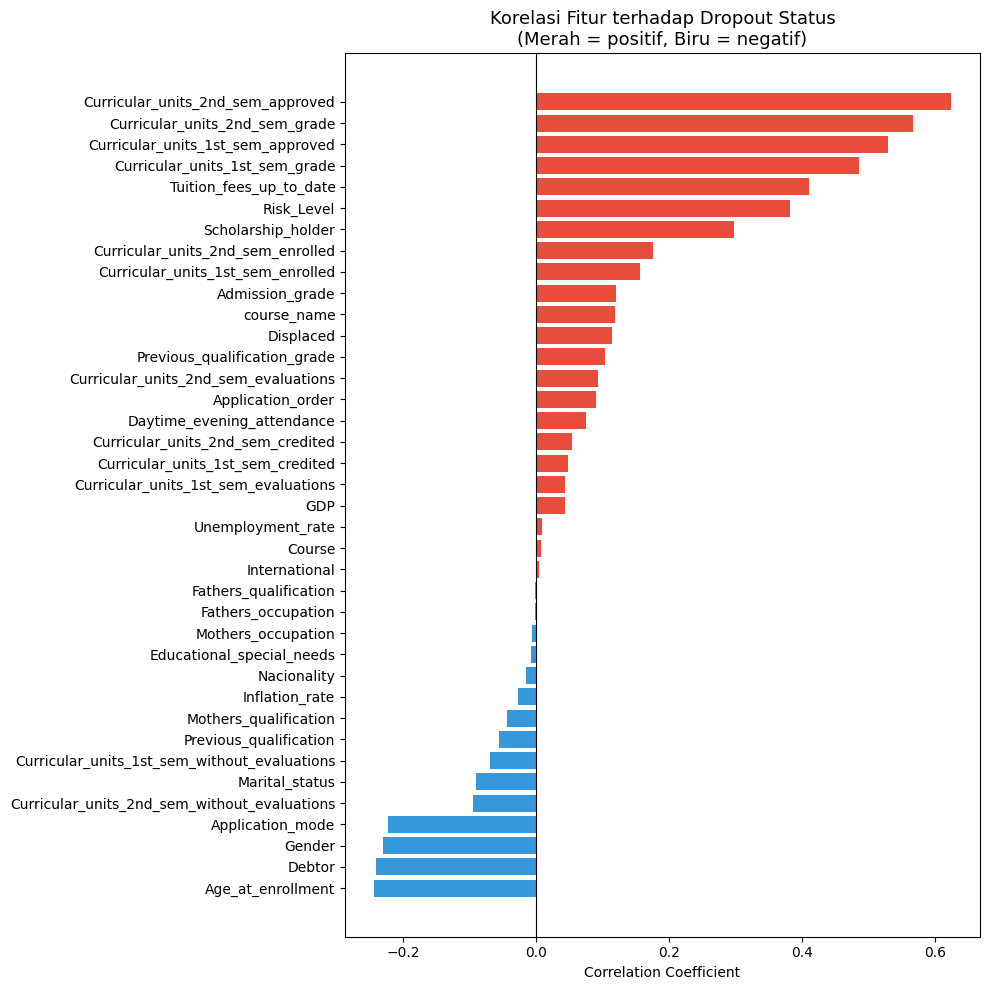


Top 10 fitur berkorelasi dengan Dropout:
Curricular_units_2nd_sem_approved    0.624157
Curricular_units_2nd_sem_grade       0.566827
Curricular_units_1st_sem_approved    0.529123
Curricular_units_1st_sem_grade       0.485207
Tuition_fees_up_to_date              0.409827
Risk_Level                           0.382131
Scholarship_holder                   0.297595
Age_at_enrollment                    0.243438
Debtor                               0.240999
Gender                               0.229270
Name: Status, dtype: float64


In [ ]:
corr_with_target = df_clean.drop(columns=['Age_Group', 'Student_ID']).corr()['Status'].drop('Status').sort_values()

plt.figure(figsize=(10, 10))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_with_target]

plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur terhadap Dropout Status\n(Merah = positif, Biru = negatif)', fontsize=13)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# top 10 fitur paling berkorelasi (positif dan negatif)
print("\nTop 10 fitur berkorelasi dengan Dropout:")
print(corr_with_target.abs().sort_values(ascending=False).head(10))

**Insight:** Visualisasi diatas menunjukkan bahwa `Curricular_units_2nd_sem_approved` menjadi fitur yang paling berkorelasi dengan dropout rate (`Status`). Fitur ini ditandai dengan warna merah dan bernilai positif. Sedangkan fitur yang paling tidak berkorelasi dengan dropout rate yaitu fitur `Age_at_enrollment`.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Remove non-numeric columns like 'Age_Group' and 'course_name' as models expect numerical input
X_model = X.drop(columns=['Age_Group', 'Student_ID'])

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y,
    test_size=0.2,
    random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # mengatasi kelas yang imbalance
    random_state=42
)
rf_model.fit(X_train, y_train)

# Ambil feature importance
feature_importance = pd.DataFrame({
    'Feature': X_model.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

                                 Feature  Importance
30     Curricular_units_2nd_sem_approved    0.116407
31        Curricular_units_2nd_sem_grade    0.080191
36                            Risk_Level    0.064690
24     Curricular_units_1st_sem_approved    0.062600
25        Curricular_units_1st_sem_grade    0.058522
29  Curricular_units_2nd_sem_evaluations    0.046400
12                       Admission_grade    0.045812
6           Previous_qualification_grade    0.039392
23  Curricular_units_1st_sem_evaluations    0.037601
19                     Age_at_enrollment    0.037365


/tmp/ipykernel_1955/1670942236.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


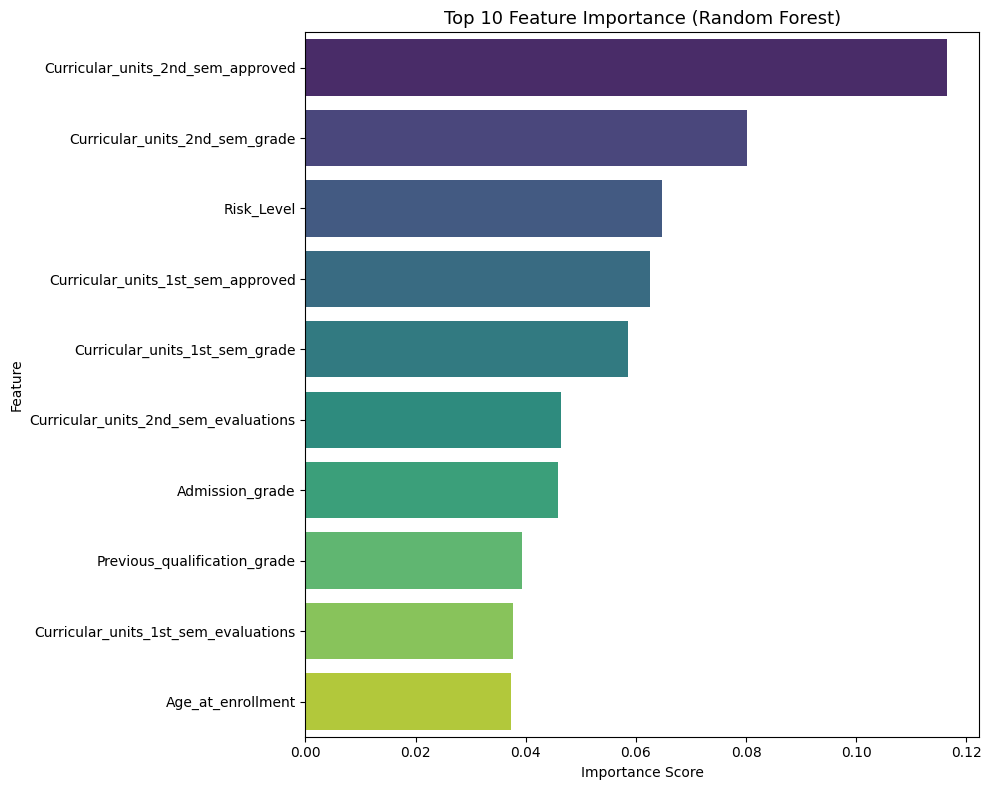

In [ ]:
# visualisasi top 10 feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(10)
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 10 Feature Importance (Random Forest)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Insight:** Visualisasi diatas menunjukkan top 10 fitur yang paling berkorelasi dengan fitur target yang dianalisis dengan RandomForest. `Curricular_2nd_sem_approveed` menjadi fitur yang paling berkorelasi dengan target.

In [ ]:
# pilih fitur akhir yang akan dipakai untuk modeling
threshold = 0.01
selected_features = feature_importance[
    feature_importance['Importance'] >= threshold
]['Feature'].tolist()

print(f"\nFitur yang dipilih ({len(selected_features)} fitur):")
print(selected_features)

# Dataset final untuk modeling
X_selected = X[selected_features]
print(f"\nShape X final: {X_selected.shape}")


Fitur yang dipilih (25 fitur):
['Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Risk_Level', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_evaluations', 'Admission_grade', 'Previous_qualification_grade', 'Curricular_units_1st_sem_evaluations', 'Age_at_enrollment', 'Fathers_occupation', 'Course', 'Mothers_occupation', 'course_name', 'Tuition_fees_up_to_date', 'GDP', 'Inflation_rate', 'Unemployment_rate', 'Mothers_qualification', 'Fathers_qualification', 'Application_mode', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_1st_sem_enrolled', 'Application_order', 'Scholarship_holder']

Shape X final: (4424, 25)


In [ ]:
# simpan data feature importance ke bentuk csv
feature_importance.to_csv('student_feature_importance.csv', index=False, sep=';', decimal=',')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

# 1. Definisikan secara spesifik Top 10 Fitur (pastikan nama kolom sama persis dengan datasetmu)
top_10_features = [
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Risk_Level',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_evaluations',
    'Admission_grade',
    'Previous_qualification_grade',
    'Curricular_units_1st_sem_evaluations',
    'Age_at_enrollment'
]

# 2. Filter X hanya untuk 10 fitur tersebut
X_top10 = df_clean[top_10_features]
y = df_clean['Status'] # Ubah 'Target' jika nama kolom labelmu berbeda (misal: 'Status')

# 3. Split data (Gunakan random_state yang sama agar konsisten)
X_train, X_test, y_train, y_test = train_test_split(X_top10, y, test_size=0.2, random_state=42, stratify=y)

# 4. SCALING ULANG (Ini menjawab pertanyaanmu)
# Kita harus membuat Scaler baru yang hanya "mengenal" 10 fitur ini
scaler_top10 = StandardScaler()
X_train_scaled = scaler_top10.fit_transform(X_train)
X_test_scaled = scaler_top10.transform(X_test)

# 5. TRAIN ULANG MODEL
# Gunakan parameter yang sama dengan model Random Forest terbaikmu sebelumnya
model_top10 = RandomForestClassifier(class_weight='balanced', random_state=42)
model_top10.fit(X_train_scaled, y_train)

# 6. Cek Akurasi Baru
y_pred = model_top10.predict(X_test_scaled)
print(f"Akurasi Model 10 Fitur: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 7. Simpan Model dan Scaler baru ke format .pkl
with open('model.pkl', 'wb') as file:
    pickle.dump(model_top10, file)

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler_top10, file)

print("Berhasil menyimpan model.pkl dan scaler.pkl!")

Akurasi Model 10 Fitur: 76.27%
Berhasil menyimpan model.pkl dan scaler.pkl!


## Modeling

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score
import seaborn as sns

target_names = ['Dropout', 'Enrolled', 'Graduate']  # urutan sesuai LabelEncoder: 0,1,2
results = {}  # simpan skor tiap model buat dibandingkan nanti

def evaluate_model(model_name, y_true, y_pred):
    print(f"===== {model_name} =====")
    print(classification_report(y_true, y_pred, target_names=target_names))

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"Macro F1-Score    : {macro_f1:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")

    results[model_name] = {'macro_f1': macro_f1, 'balanced_accuracy': bal_acc}

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [ ]:
# split data train & test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42)

print(f"\nShape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")


Shape X_train: (3539, 25)
Shape X_test: (885, 25)


**Insight:** dataset final dengan 23 fitur terpilih berhasil dibagi menjadi data latih (80% = 3.539 baris) dan data uji (20% = 885 baris). `random_state=42` digunakan untuk memastikan hasil yang dapat direproduksi. Data latih akan digunakan untuk melatih model, sedangkan data uji akan digunakan untuk mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya.

Akurasi: 74.01%
===== Logistic Regression =====
              precision    recall  f1-score   support

     Dropout       0.86      0.70      0.77       316
    Enrolled       0.41      0.58      0.48       151
    Graduate       0.83      0.83      0.83       418

    accuracy                           0.74       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.74      0.75       885

Macro F1-Score    : 0.6950
Balanced Accuracy : 0.7030


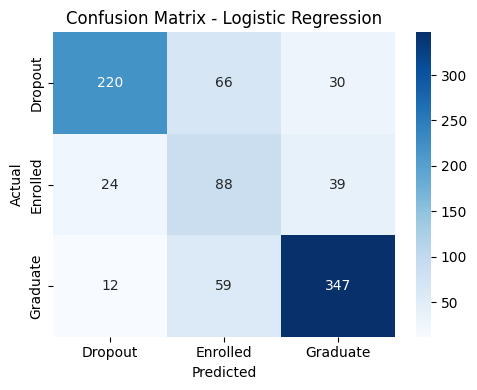

In [ ]:
# train dengan Logistic Regression sebagai baseline model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi: {accuracy * 100:.2f}%")
evaluate_model('Logistic Regression', y_test, y_pred)

**Insight:** model Logistic Regression berhasil dilatih sebagai model baseline. `StandardScaler` diterapkan terlebih dahulu karena Logistic Regression sensitif terhadap perbedaan skala antar fitur. Sebagai model linear yang sederhana, Logistic Regression berfungsi sebagai acuan bawah untuk membandingkan performa model yang lebih kompleks.

Akurasi: 75.93%
===== XGBoost =====
              precision    recall  f1-score   support

     Dropout       0.84      0.73      0.78       316
    Enrolled       0.48      0.49      0.48       151
    Graduate       0.80      0.88      0.84       418

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.76      0.76       885

Macro F1-Score    : 0.7022
Balanced Accuracy : 0.6997


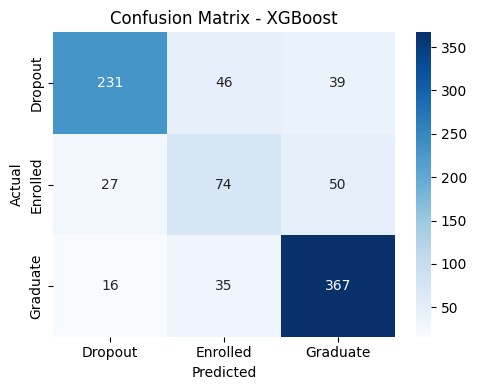

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = XGBClassifier()
model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi: {accuracy * 100:.2f}%")
evaluate_model('XGBoost', y_test, y_pred)

Akurasi: 76.72%
===== Random Forest =====
              precision    recall  f1-score   support

     Dropout       0.82      0.77      0.79       316
    Enrolled       0.54      0.33      0.41       151
    Graduate       0.78      0.93      0.84       418

    accuracy                           0.77       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.77      0.75       885

Macro F1-Score    : 0.6828
Balanced Accuracy : 0.6743


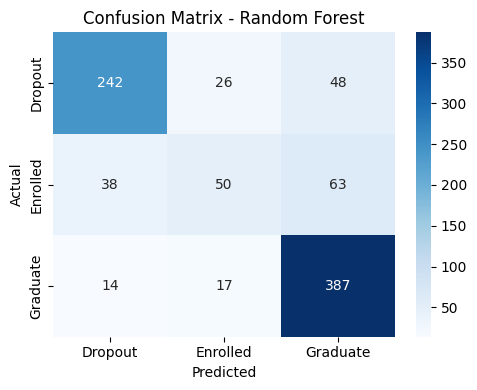

In [ ]:
# train dengan random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi: {accuracy * 100:.2f}%")
evaluate_model('Random Forest', y_test, y_pred)

## Evaluation

                     macro_f1  balanced_accuracy
XGBoost              0.702176           0.699690
Logistic Regression  0.694961           0.703043
Random Forest        0.682752           0.674262


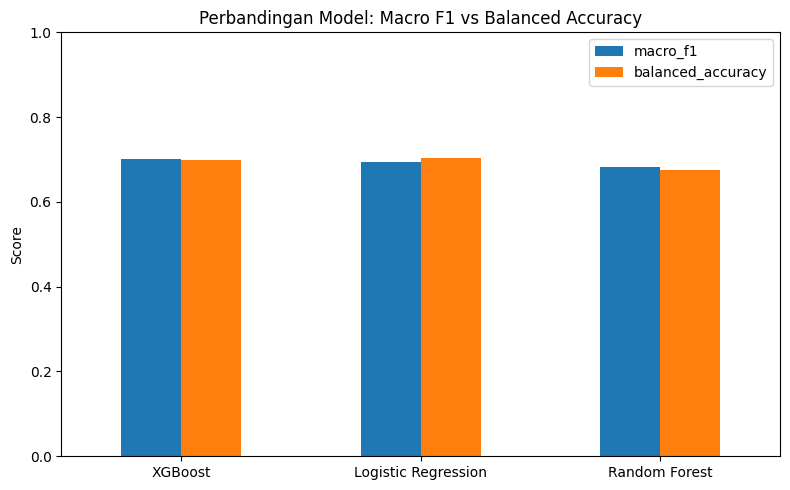

In [ ]:
comparison_df = pd.DataFrame(results).T.sort_values('macro_f1', ascending=False)
print(comparison_df)

comparison_df.plot(kind='bar', figsize=(8, 5))
plt.title('Perbandingan Model: Macro F1 vs Balanced Accuracy')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Insight:** berdasarkan evaluasi ketiga model pada data uji, berikut ringkasan performa yang dihasilkan:

| Model | Accuracy | Precission | Recall (Attrition) | F1 (Attrition) |
|---|---|---|---|---|
| Logistic Regression | 0.74 | 0.86 | 0.70 | 0.77 |
| **Random Forest** | **0.77** | **0.82**| **0.77** | **0.79**  |
| XGBoost | 0.76 | 0.84 | 0.73 | 0.78 |

**Model terbaik: Random Forest** dengan recall 0.77 untuk kelas dropout. Meskipun XGBoost memiliki skor recall yang sama dengan model Random Forest, accuracy-nya terhadap kelas dropour lebih rendah (0.76), artinya model hanya mampu mendeteksi 76% mahasiswa yang benar-benar dropout dan ada sekitar 24% mahasiswa yang tidak berhasil diterprediksi. Random Forest mampu mendeteksi 77% dari seluruh karyawan berisiko, menjadikannya pilihan paling tepat untuk kebutuhan departemen HR yang mengutamakan sensitivitas deteksi dini.

In [ ]:
import joblib

joblib.dump(model, 'model_dropout_rf.joblib')
joblib.dump(scaler, 'scaler_dropout.joblib')
joblib.dump(selected_features, 'selected_features.joblib')
joblib.dump(encoders, 'label_encoders.joblib')

print("Model, scaler, daftar fitur, dan encoder berhasil disimpan.")

Model, scaler, daftar fitur, dan encoder berhasil disimpan.


## Kesimpulan Hasil Analisis

- Masalah dropout di Jaya Jaya Institut berada pada angka yang tergolong tinggi (32.1%), dengan pemicu utama kegagalan meluluskan SKS pada dua semester pertama dan kendala pembayaran UKT.
- Model Machine Learning Random Forest berhasil memprediksi potensi dropout dengan akurasi 76.27% berbasis 10 indikator utama.
- Perlunya integrasi Dashboard BI dan Simulator Streamlit untuk memberikan visibilitas penuh bagi dosen pembimbing untuk melakukan intervensi proaktif sebelum mahasiswa mengambil keputusan berhenti kuliah.

## Rekomendasi / Action Items

1. **Penerapan Early Warning System (Sistem Peringatan Dini):**
Mewajibkan dosen wali/pembimbing akademis menggunakan simulator prediksi Streamlit setiap akhir Semester 1 untuk mengidentifikasi mahasiswa dengan status High Risk.

2. **Program Pendampingan & Mentoring Akademis Khusus:**
Membentuk program Peer Tutoring (tutor sebaya) dan klinik akademik bagi mahasiswa yang mengumpulkan SKS lulus < 4 unit di Semester 1.

3. **Skema Bantuan Finansial & Cicilan UKT Fleksibel:**
Menyediakan opsi perpanjangan waktu atau cicilan pembayaran UKT bagi mahasiswa berstatus Debtor sebelum memasuki masa pendaftaran ulang semester baru, guna mencegah dropout yang disebabkan alasan ekonomi.

4. **Monitoring Beasiswa Tepat Sasaran:**
Melakukan evaluasi berkala terhadap penerima beasiswa agar dapat mempertahankan Indeks Prestasi Kumulatif (IPK) dan tidak kehilangan hak beasiswa di semester berikutnya.